### COVID-19 확진자 예측 모델링

In [1]:
# 데이터 재수집 & 전처리
import pandas as pd

# COVID-19 데이터 (Johns Hopkins University)
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(url)

# 미국 데이터만 필터링 및 전처리
us_data = df[df['Country/Region'] == 'US'].iloc[:, 4:].T
us_data = us_data.reset_index()
us_data.columns = ['Date', 'Confirmed']
us_data['Date'] = pd.to_datetime(us_data['Date'])

C:\Users\mj985\AppData\Local\Temp\ipykernel_11544\2623219515.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us_data['Date'] = pd.to_datetime(us_data['Date'])


In [2]:
!pip install prophet


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Prophet을 이용한 시계열 예측
import prophet
from prophet import Prophet 

# Prophet용 데이터 포맷팅 (ds: 날짜, y: 타겟 값)
prophet_df = us_data.rename(columns={'Date': 'ds', 'Confirmed': 'y'})

# 모델 훈련
model = Prophet(weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# 30일 뒤까지 예측
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

12:37:24 - cmdstanpy - INFO - Chain [1] start processing
12:37:25 - cmdstanpy - INFO - Chain [1] done processing


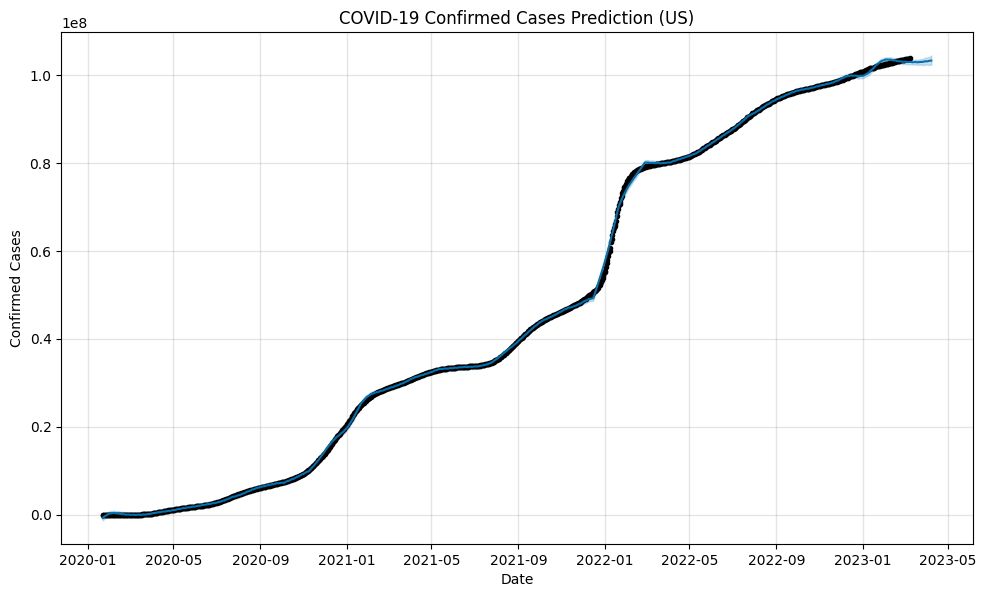

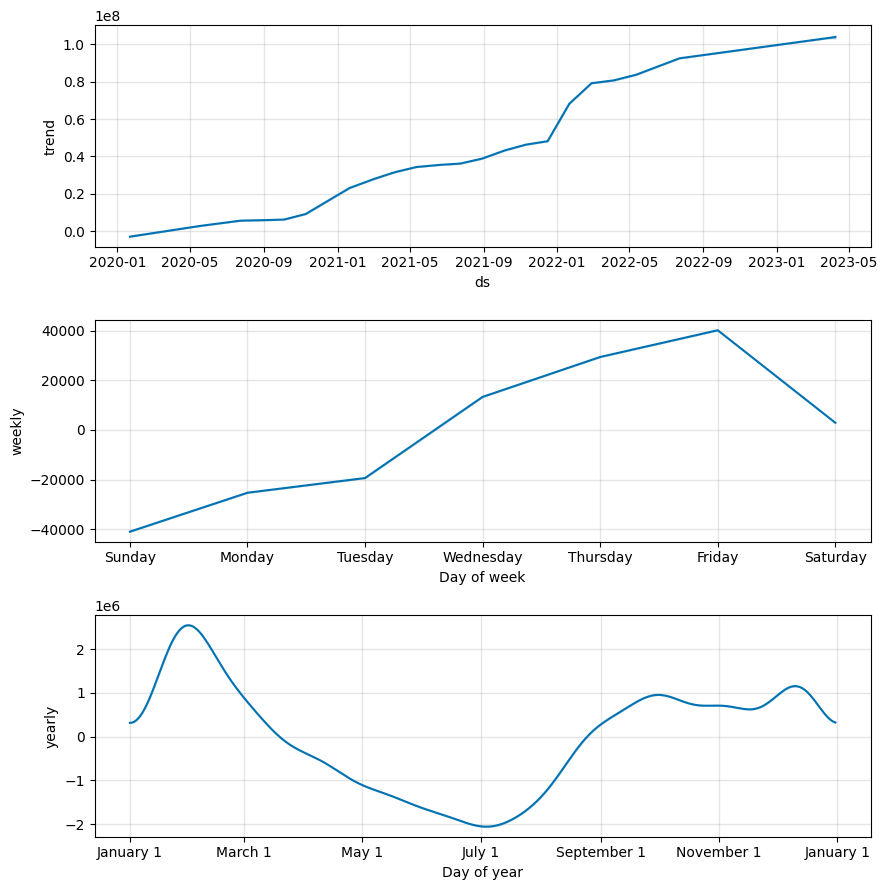

In [6]:
# 예측 결과 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 상위 폴더의 visuals 폴더 경로
visuals_folder_path = '../visuals'

# 트렌드 및 예측 그래프
fig1 = model.plot(forecast)
plt.title("COVID-19 Confirmed Cases Prediction (US)")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

# 그래프 저장
plt.savefig(os.path.join(visuals_folder_path, 'covid19_prediction_trend.png'), bbox_inches='tight')
plt.show()
plt.close()  # 현재 그래프 닫기

# 주간/연간 계절성 분석
fig2 = model.plot_components(forecast)

# 그래프 저장
plt.savefig(os.path.join(visuals_folder_path, 'covid19_seasonality_analysis.png'), bbox_inches='tight')
plt.show()
plt.close()  # 현재 그래프 닫기